# Fedora CommBlog RAG — Exploration Notebook

This notebook is used for hands-on experimentation throughout the mini-project.

**Sections:**
1. Dataset Overview
2. Quality Report Analysis
3. Chunking Strategy Experiments
4. RAG Query Testing
5. Benchmark Results Visualization


---
## 0. Setup & Imports

In [1]:
import json
import os
import re
import subprocess
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paths
RAW_DIR     = Path('../data/raw')
CLEANED_DIR = Path('../data/cleaned')
RESULTS_DIR = Path('../results')

print('Paths configured.')
print(f'  Raw articles     : {len(list(RAW_DIR.glob("*.json")) if RAW_DIR.exists() else [])}')
print(f'  Cleaned articles : {len(list(CLEANED_DIR.glob("*.md")) if CLEANED_DIR.exists() else [])}')


Paths configured.
  Raw articles     : 1790
  Cleaned articles : 1789


---
## 1. Dataset Overview

Explore what we fetched from the WordPress REST API.

In [2]:
# Load the article index
index_path = RAW_DIR / 'index.json'

with open(index_path, 'r', encoding='utf-8') as f:
    index = json.load(f)

df = pd.DataFrame(index)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

print(f'Total articles: {len(df)}')
print(f'Date range    : {df["date"].min().date()} → {df["date"].max().date()}')
df.head(10)


Total articles: 1789
Date range    : 2015-10-20 → 2026-05-22


,id,slug,title,date,link,year
0,15676,community-update-week-21-2026,Community Update &#8211; Week 21 2026,2026-05-22 10:00:00,https://communityblog.fedoraproject.org/commun...,2026
1,15488,fedora-and-centos-scale-23x-2026,Fedora and CentOS @ SCALE 23x 2026,2026-05-21 08:17:17,https://communityblog.fedoraproject.org/fedora...,2026
2,15668,community-update-week-20,Community Update &#8211; Week 20,2026-05-15 15:09:12,https://communityblog.fedoraproject.org/commun...,2026
3,15664,f44-election-nominations-now-open,F44 election nominations now open,2026-05-13 20:38:01,https://communityblog.fedoraproject.org/f44-el...,2026
4,15647,community-update-week-19-2026,Community Update &#8211; Week 19 2026,2026-05-08 10:00:00,https://communityblog.fedoraproject.org/commun...,2026
5,15646,community-update-week-18-2026,"Community Update &#8211; Week 18, 2026",2026-05-06 14:37:01,https://communityblog.fedoraproject.org/commun...,2026
6,15633,join-us-for-podman-6-0-test-days-may-11-15-2026,Join Us for Podman 6.0 Test Days &#8211; May 1...,2026-05-05 11:56:11,https://communityblog.fedoraproject.org/join-u...,2026
7,15607,throwing-random-arguments-at-system-binaries-r...,Throwing Random Arguments at System Binaries: ...,2026-04-28 12:00:00,https://communityblog.fedoraproject.org/throwi...,2026
8,15619,community-update-week-17-2026,Community Update &#8211; Week 17 2026,2026-04-24 12:00:00,https://communityblog.fedoraproject.org/commun...,2026
9,15584,fedora-verified-recognize-contributors,Fedora Verified: Help Shape a New Way to Recog...,2026-04-21 12:02:00,https://communityblog.fedoraproject.org/fedora...,2026


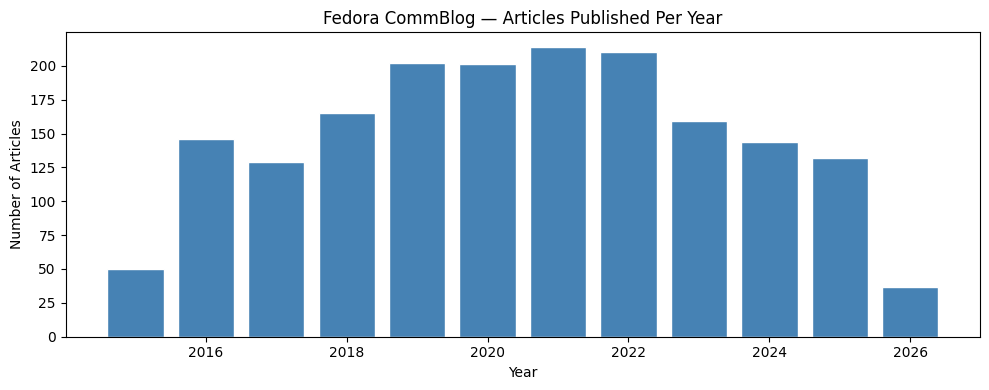

In [3]:
# Articles published per year
yearly = df.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(yearly['year'], yearly['count'], color='steelblue', edgecolor='white')
ax.set_title('Fedora CommBlog — Articles Published Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Articles')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()


---
## 2. Quality Report Analysis

Review the output of `clean_dataset.py` to understand dataset health.

In [4]:
# Load quality report
report_path = CLEANED_DIR / 'quality_report.json'

with open(report_path, 'r', encoding='utf-8') as f:
    report = json.load(f)

qdf = pd.json_normalize(report)
print(f'Articles in report: {len(qdf)}')
qdf.head()


Articles in report: 1789


,slug,title,quality.has_featured_image,quality.has_more_tag,quality.has_headings,quality.has_min_length,quality.has_title,quality.has_date,quality.passed
0,community-update-week-21-2026,Community Update &#8211; Week 21 2026,False,False,True,True,True,True,False
1,fedora-and-centos-scale-23x-2026,Fedora and CentOS @ SCALE 23x 2026,False,False,True,True,True,True,False
2,community-update-week-20,Community Update &#8211; Week 20,False,False,True,True,True,True,False
3,f44-election-nominations-now-open,F44 election nominations now open,False,False,False,True,True,True,False
4,community-update-week-19-2026,Community Update &#8211; Week 19 2026,False,False,True,True,True,True,False


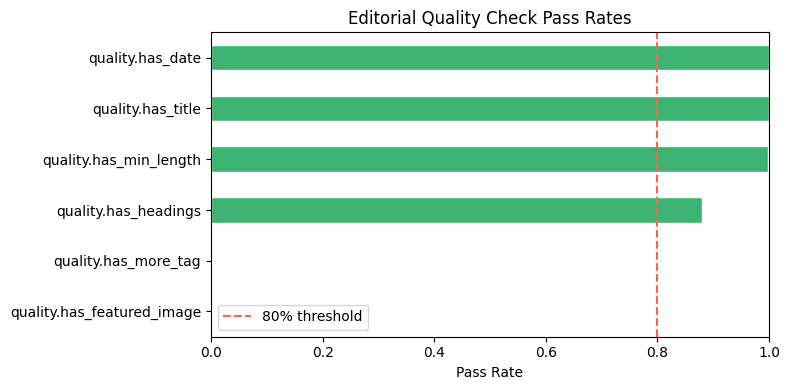

In [5]:
# Quality check pass rates
check_cols = [c for c in qdf.columns if c.startswith('quality.') and c != 'quality.passed']
pass_rates = qdf[check_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
pass_rates.plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Editorial Quality Check Pass Rates')
ax.set_xlabel('Pass Rate')
ax.set_xlim(0, 1)
ax.axvline(0.8, color='tomato', linestyle='--', label='80% threshold')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# Articles that failed quality checks — inspect them
failed = qdf[qdf['quality.passed'] == False][['slug', 'title'] + check_cols]
print(f'Failed articles: {len(failed)}')
failed


Failed articles: 1789


,slug,title,quality.has_featured_image,quality.has_more_tag,quality.has_headings,quality.has_min_length,quality.has_title,quality.has_date
0,community-update-week-21-2026,Community Update &#8211; Week 21 2026,False,False,True,True,True,True
1,fedora-and-centos-scale-23x-2026,Fedora and CentOS @ SCALE 23x 2026,False,False,True,True,True,True
2,community-update-week-20,Community Update &#8211; Week 20,False,False,True,True,True,True
3,f44-election-nominations-now-open,F44 election nominations now open,False,False,False,True,True,True
4,community-update-week-19-2026,Community Update &#8211; Week 19 2026,False,False,True,True,True,True
...,...,...,...,...,...,...,...,...
1784,fedora-24-release-dates-and-schedule,Fedora 24 release dates and schedule,False,False,False,True,True,True
1785,fedora-outreachy-application-window-closed,Fedora Outreachy Application Window Closed,False,False,True,True,True,True
1786,introducing-fedora-community-blog,Introducing the Fedora Community Blog,False,False,True,True,True,True
1787,fedora-23-release-is-a-go,Fedora 23 Release is a GO!,False,False,True,True,True,True


---
## 3. Chunking Strategy Experiments

Test different chunk sizes to find the best balance for RAG retrieval.

In [7]:
def chunk_text(text: str, chunk_size: int, overlap: int) -> list[str]:
    """Simple token-approximation chunker (1 token ≈ 4 chars)."""
    words = text.split()
    chunks = []
    step = max(1, chunk_size - overlap)
    for i in range(0, len(words), step):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    return chunks


# Load a sample article
sample_files = list(CLEANED_DIR.glob('*.md'))[:1]
if sample_files:
    sample_text = sample_files[0].read_text(encoding='utf-8')
    print(f'Sample article: {sample_files[0].name}')
    print(f'Length: {len(sample_text.split())} words')
else:
    print('No cleaned articles found yet.')


Sample article: community-update-week-21-2026.md
Length: 747 words


In [8]:
# Compare chunk counts across different chunk sizes
if sample_files:
    chunk_sizes = [128, 256, 512, 1024]
    overlap = 64

    results = []
    for cs in chunk_sizes:
        chunks = chunk_text(sample_text, cs, overlap)
        avg_len = sum(len(c.split()) for c in chunks) / len(chunks) if chunks else 0
        results.append({'chunk_size': cs, 'num_chunks': len(chunks), 'avg_words': round(avg_len, 1)})

    chunk_df = pd.DataFrame(results)
    print(chunk_df.to_string(index=False))


 chunk_size  num_chunks  avg_words
        128          12      119.2
        256           4      234.8
        512           2      405.5
       1024           1      747.0


---
## 4. RAG Query Testing

Run live queries against the RamaLama RAG pipeline.

> **Prerequisites:** RamaLama must be installed and models pulled.

In [9]:
# ── RamaLama RAG — Correct Workflow ──────────────────────────────────────────
#
# RamaLama RAG works in TWO steps:
#
#   Step 1 — Build: convert your corpus into an OCI image (vector store)
#     ramalama rag <corpus_dir> <oci_image_name>
#
#   Step 2 — Run: query a model using that OCI image
#     ramalama run --rag <oci_image_name> <model>
#
# OR use the quick ad-hoc flag (no OCI image needed, good for testing):
#     ramalama run --nocontainer --rag <corpus_dir> <model>
#
# References:
#   https://docs.ramalama.com/cli/commands/ramalama/rag
#   https://blog.ramalama.com/on-the-fly-document-context-with-ramalama/

import subprocess
import os

# ── Config ────────────────────────────────────────────────────────────────────
CORPUS_DIR = '../data/cleaned'
RAG_IMAGE  = f'quay.io/{os.getenv("USER", "myuser")}/fedora-commblog-rag'


def build_rag_store(
    corpus_dir: str = CORPUS_DIR,
    image: str = RAG_IMAGE,
    chunk_size: int = 256,
) -> bool:
    """
    Step 1 — Build the RAG vector store from the corpus.
    Converts all Markdown files into an OCI image using Docling + Qdrant.
    Requires Podman to be running.

    Command: ramalama rag --chunk-size <n> <corpus_dir> <oci_image>

    chunk_size=256 stays safely under the 512-token embedder batch limit.
    The default of 400 caused a 593-token overflow error.
    """
    print(f'Building RAG store from : {corpus_dir}')
    print(f'Target OCI image        : {image}')
    print(f'Chunk size              : {chunk_size} tokens')
    print('This may take a few minutes...\n')

    cmd = [
        'ramalama', 'rag',
        '--chunk-size', str(chunk_size),
        corpus_dir,
        image,
    ]
    result = subprocess.run(cmd, text=True, timeout=600)

    if result.returncode != 0:
        print(f'ERROR: RAG store build failed (exit code {result.returncode})')
        return False

    print(f'\n✅ RAG store built successfully → {image}')
    return True


def query_rag_interactive(model: str, image: str = RAG_IMAGE) -> None:
    """
    Step 2 — Run a model interactively against the RAG OCI image.
    Drops into an interactive prompt — type your query there.

    Command: ramalama run --rag <oci_image> <model>
    """
    print(f'Launching interactive RAG session...')
    print(f'  Model : {model}')
    print(f'  RAG   : {image}')
    print('Type your query at the prompt. Ctrl+D to exit.\n')

    cmd = ['ramalama', 'run', '--rag', image, model]
    subprocess.run(cmd)  # Interactive — no capture


def query_rag_adhoc(model: str, prompt: str, corpus_dir: str = CORPUS_DIR) -> str:
    """
    Ad-hoc query — no OCI image needed.
    Injects the corpus directly into the model context at runtime.
    Best for quick testing before building the full RAG store.

    Command: ramalama run --nocontainer --rag <corpus_dir> <model>
    Note: runs non-interactively by piping the prompt via stdin.
    """
    cmd = [
        'ramalama', 'run',
        '--nocontainer',
        '--rag', corpus_dir,
        model,
    ]
    result = subprocess.run(
        cmd,
        input=prompt,
        capture_output=True,
        text=True,
        timeout=180,
    )
    if result.returncode != 0:
        return f'ERROR: {result.stderr.strip()}'
    return result.stdout.strip()


print('RamaLama RAG helpers loaded.')
print(f'  RAG image target : {RAG_IMAGE}')
print(f'  Corpus dir       : {CORPUS_DIR}')


RamaLama RAG helpers loaded.
  RAG image target : quay.io/gtfrans2re/fedora-commblog-rag
  Corpus dir       : ../data/cleaned


In [11]:
# ── Step 1: Build the RAG vector store (run once) ────────────────────────────
# Requires: Podman running + data/cleaned/ populated
# Uncomment when ready:

build_rag_store()


  Embedding 6687/11909 chunks...Starting VLM server...
Starting embedding server...


Building RAG store from : ../data/cleaned
Target OCI image        : quay.io/gtfrans2re/fedora-commblog-rag
Chunk size              : 256 tokens
This may take a few minutes...



  Embedding 6695/11909 chunks...

7fc94d1b60ca1ed90f0458b982baa51f015dfb98c641168940a44404751b74ce
188f52f5c1d1f084db63b707a4018992ad13454e7577bc44cf031c62abd7d84e


  Embedding 6711/11909 chunks...VLM server is ready.
  Embedding 6712/11909 chunks...Embedding server is ready.
  Embedding 6714/11909 chunks...Found 1789 file(s): 0 need VLM, 1789 text-only
Reading 2015-december-elections-interviews.md (1/1789)...
Reading 2016-july-elections-interviews.md (2/1789)...
Reading 2017-january-elections-interviews.md (3/1789)...
Reading 2018-may-elections-council-mindshare-interviews.md (4/1789)...
Reading 2018-may-elections-fesco-interviews.md (5/1789)...
Reading 2023-year-in-review-cpe.md (6/1789)...
Reading 2023-year-in-review-infra-releng.md (7/1789)...
Reading 2024-git-forge-evaluation.md (8/1789)...
Reading 2025-fedora-datacenter-move-update.md (9/1789)...
Reading 30-projects-migrated-their-translation-to-weblate-what-about-yours.md (10/1789)...
Reading 316-2.md (11/1789)...
Reading 9336-2.md (12/1789)...
Reading a-closer-look-at-fedora-projects.md (13/1789)...
Reading a-new-conceptual-model-for-fedora.md (14/1789)...
Reading a-new-way-to-find-a-packa

TimeoutExpired: Command '['ramalama', 'rag', '--chunk-size', '256', '../data/cleaned', 'quay.io/gtfrans2re/fedora-commblog-rag']' timed out after 600 seconds

  Embedding 11909/11909 chunks...
  Embedding 5329/11909 chunks...Stored 11909 vectors in Qdrant
  Embedding 11909/11909 chunks...
Stored 11909 vectors in Qdrant


In [12]:
# ── Step 2a: Interactive session (full RAG pipeline) ─────────────────────────
# Requires Step 1 (build_rag_store) to have completed successfully first.
#
# IMPORTANT: Use HuggingFace model format — ollama:// is deprecated in ramalama.
# From your pulled models (ramalama list), use:
#   'hf://Qwen/Qwen3-4B-GGUF'             instead of 'qwen2.5:7b'
#   'hf://Qwen/Qwen3-1.7B-GGUF'           instead of 'smollm2:1.7b'
#   'hf://ggml-org/gemma-3-4b-it-GGUF'    (already correct)
#   'hf://instructlab/granite-7b-lab-GGUF/granite-7b-lab-Q4_K_M.gguf'  for Granite
#
# Uncomment when ready:

query_rag_interactive('hf://Qwen/Qwen3-4B-GGUF')


Launching interactive RAG session...
  Model : hf://Qwen/Qwen3-4B-GGUF
  RAG   : quay.io/gtfrans2re/fedora-commblog-rag
Type your query at the prompt. Ctrl+D to exit.



Error: quay.io/gtfrans2re/fedora-commblog-rag:latest does not exist.


In [ ]:
# ── Step 2b: Ad-hoc query (quick test, no OCI image needed) ──────────────────
# Good for fast iteration while the full RAG store isn't built yet.
# Uses HuggingFace model format (ollama:// is deprecated in ramalama).

MODEL  = 'hf://Qwen/Qwen3-4B-GGUF'   # Already pulled — from ramalama list
PROMPT = 'What tone should a Fedora Community Blog article use?'

# Uncomment to run:
response = query_rag_adhoc(MODEL, PROMPT)
print(response)


In [ ]:
# ── Side-by-side model comparison (ad-hoc) ───────────────────────────────────
# All models use HuggingFace format — matches what's in your ramalama list.
MODELS = [
    'hf://Qwen/Qwen3-4B-GGUF',
    'hf://Qwen/Qwen3-1.7B-GGUF',
    'hf://ggml-org/gemma-3-4b-it-GGUF',
    'hf://instructlab/granite-7b-lab-GGUF/granite-7b-lab-Q4_K_M.gguf',
]
TEST_PROMPT = 'What are the required elements for a Fedora Community Blog article?'

# Uncomment to run (takes time — one model at a time):
for model in MODELS:
     print(f'\n=== {model} ===')
     print(query_rag_adhoc(model, TEST_PROMPT))


---
## 5. Benchmark Results Visualization

Visualize results from `scripts/benchmark.py`.

In [ ]:
# Load the most recent benchmark result
result_files = sorted(RESULTS_DIR.glob('benchmark_*.json')) if RESULTS_DIR.exists() else []

if not result_files:
    print('No benchmark results found yet. Run scripts/benchmark.py first.')
else:
    latest = result_files[-1]
    with open(latest, 'r', encoding='utf-8') as f:
        bench = json.load(f)
    print(f'Loaded: {latest.name}')
    print(f'Models tested: {[m["label"] for m in bench["models"]]}')


In [ ]:
# Plot: average latency vs keyword score per model
if result_files:
    labels   = [m['label'] for m in bench['models']]
    latency  = [m['avg_latency_s'] for m in bench['models']]
    scores   = [m['avg_keyword_score'] for m in bench['models']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.barh(labels, latency, color='steelblue', edgecolor='white')
    ax1.set_title('Average Latency (s)')
    ax1.set_xlabel('Seconds')

    ax2.barh(labels, scores, color='mediumseagreen', edgecolor='white')
    ax2.set_title('Average Keyword Score')
    ax2.set_xlabel('Score (0–1)')
    ax2.set_xlim(0, 1)

    plt.suptitle('Model Benchmark Comparison', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [ ]:
# Per-prompt breakdown heatmap
if result_files:
    prompt_ids = [p['id'] for p in bench['models'][0]['prompts']]
    heatmap_data = [
        [p['keyword_score'] for p in m['prompts']]
        for m in bench['models']
    ]
    hm_df = pd.DataFrame(heatmap_data, index=labels, columns=prompt_ids)

    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(hm_df.values, cmap='YlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(prompt_ids)))
    ax.set_xticklabels(prompt_ids, rotation=30, ha='right')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    plt.colorbar(im, ax=ax, label='Keyword Score')
    ax.set_title('Per-Prompt Keyword Score Heatmap')
    plt.tight_layout()
    plt.show()


---
## 6. Notes & Observations

Use this cell to jot down observations as you experiment.

| Date | Observation |
|------|-------------|
| | |
